In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Matplotlib style configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Load Data

In [2]:
df = pd.read_excel('data/marketing_campaign_dataset.xlsx')
df.head(2)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas


## Funnel Analysis

In [3]:
# Do people see the ad but don’t click?

df['CTR'] = df['Clicks'] / (df['Impressions'] + 1)

df["CTR"].describe()

count   200005.00
mean         0.14
std          0.13
min          0.01
25%          0.06
50%          0.10
75%          0.17
max          0.99
Name: CTR, dtype: float64

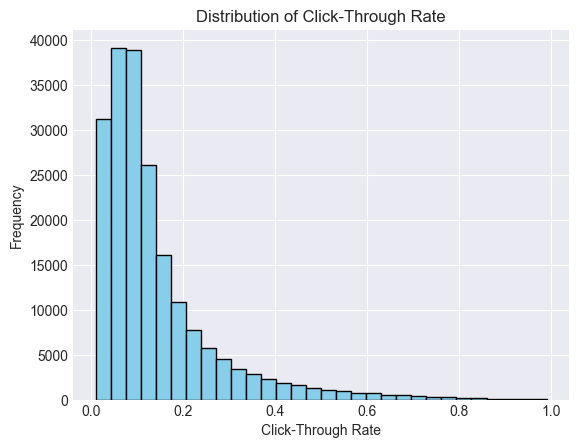

In [4]:
# Distribution of Click-Through Rate
plt.Figure(figsize=(10, 6))
plt.hist(df["CTR"], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Click-Through Rate')
plt.xlabel('Click-Through Rate')
plt.ylabel('Frequency')
plt.show()

# Insights:
# 1. The average CTR is around 0.14, which means that on average, 14% of the people who see the ad click on it.
# 2. The distribution of CTR is right-skewed, indicating that while most ads have a low CTR, there are a few ads with very high CTRs.
# 3. The presence of outliers with very high CTRs suggests that some ads are performing exceptionally well, 
#    which could be worth investigating further to understand what makes them successful.

In [5]:
# A weak CTR could indicate that the ad is not relevant to the audience, 
# the ad creative is not compelling, or there are issues with the targeting. 
# It’s important to analyze the factors contributing to a low CTR and make adjustments to improve ad performance.

In [6]:
# Conversion_Rate = conversions / clicks 
# Add a new column for conversions based on the conversion rate and clicks
df['conversions'] = df['Conversion_Rate'] * df['Clicks']

In [7]:
# let's investegate the hightest the ctr above the 75% of the data which is above CTR > 0.17
df[df['CTR'] >= 0.17].describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,CTR,conversions
count,49844.00,49844.00,49844.00,49844.00,49844.00,49844.00,49844.00,49844.00,49844.00
mean,100116.48,0.08,12506.81,5.00,723.90,2632.91,5.47,0.32,58.00
std,57629.03,0.04,4348.77,1.73,195.42,1154.66,2.87,0.15,34.24
min,1.00,0.01,5000.00,2.00,174.00,1000.00,1.00,0.17,2.01
25%,50266.25,0.05,8730.00,3.50,586.00,1652.00,3.00,0.21,29.21
50%,100544.00,0.08,12492.00,5.01,757.00,2439.00,5.00,0.27,53.53
75%,149850.00,0.11,16284.00,6.50,889.00,3459.00,8.00,0.38,82.81
max,200004.00,0.15,20000.00,8.00,1000.00,5868.00,10.00,0.99,150.00


In [8]:
# check the distribution of the CTR above 0.17 which is the 75% of the data
df[df['CTR'] >= 0.17]

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,CTR,conversions
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness,0.26,20.24
8,9,Alpha Innovations,Social Media,Women 35-44,15 days,Facebook,0.09,18066,6.73,Chicago,2021-09-01 00:00:00,861,1754,6,Tech Enthusiasts,0.49,77.49
13,14,TechCorp,Email,Men 25-34,45 days,Instagram,0.14,9975,7.06,New York,14/01/2021,994,2201,4,Health & Wellness,0.45,139.16
15,16,Innovate Industries,Social Media,Women 35-44,60 days,YouTube,0.11,9407,2.91,New York,16/01/2021,299,1512,5,Health & Wellness,0.20,32.89
16,17,Innovate Industries,Display,Women 35-44,45 days,Website,0.08,5478,4.53,Houston,17/01/2021,931,2488,3,Fashionistas,0.37,74.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199985,199986,DataTech Solutions,Email,Women 25-34,60 days,YouTube,0.03,10572,2.16,Miami,22/11/2021,691,3491,9,Tech Enthusiasts,0.20,20.73
199987,199988,Alpha Innovations,Search,Women 25-34,15 days,Instagram,0.14,13465,7.54,Miami,24/11/2021,996,4654,3,Tech Enthusiasts,0.21,139.44
199993,199994,DataTech Solutions,Search,All Ages,15 days,Website,0.13,5665,5.56,Miami,30/11/2021,460,2397,7,Fashionistas,0.19,59.80
199994,199995,DataTech Solutions,Email,Women 25-34,15 days,Email,0.10,9453,5.44,Miami,2021-01-12 00:00:00,301,1107,9,Tech Enthusiasts,0.27,30.10


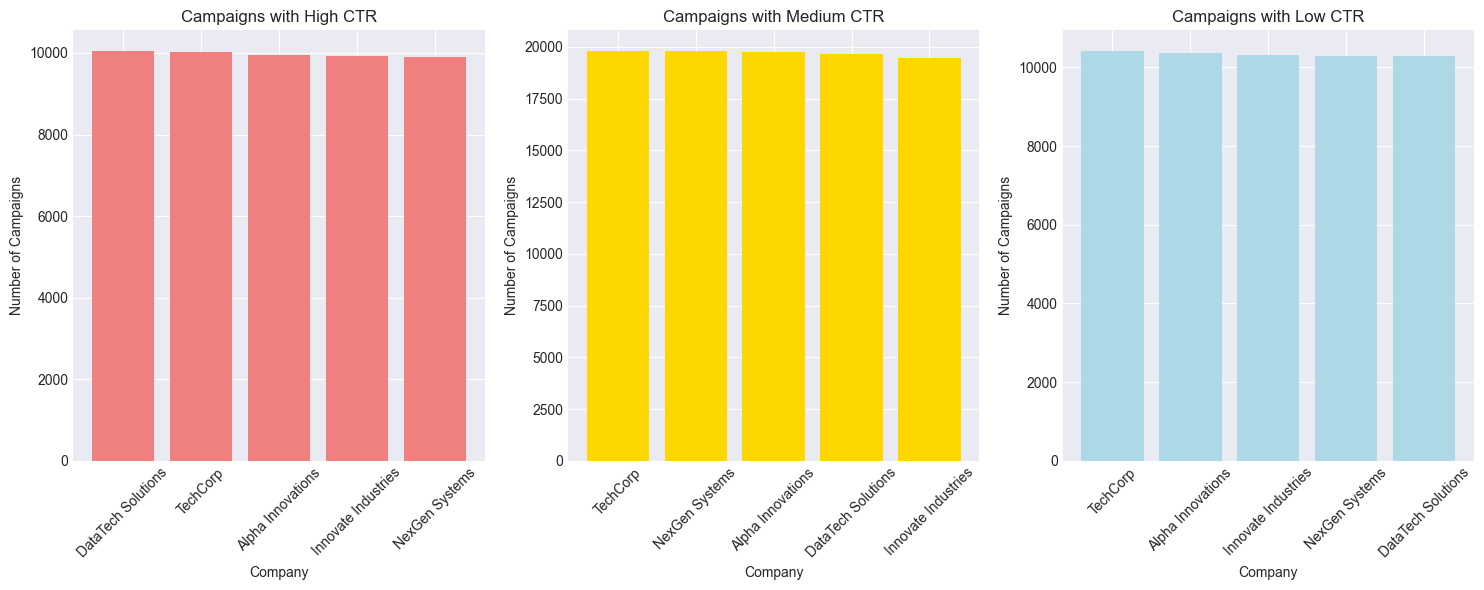

In [9]:
# Let's visualize the distribution of campaigns across companies based on their CTR categories (High, Medium, Low).

fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# High CTR
high_ctr = df[df['CTR'] >= 0.17]
axs[0].bar(
    high_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    high_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='lightcoral'
)
axs[0].set_xlabel('Company')
axs[0].set_ylabel('Number of Campaigns')
axs[0].set_title('Campaigns with High CTR')
axs[0].tick_params(axis='x', rotation=45)

# Medium CTR ( 0.06 و 0.17)
medium_ctr = df[(df['CTR'] < 0.17) & (df['CTR'] > 0.06)]
axs[1].bar(
    medium_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    medium_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='gold'
)
axs[1].set_xlabel('Company')
axs[1].set_ylabel('Number of Campaigns')
axs[1].set_title('Campaigns with Medium CTR')
axs[1].tick_params(axis='x', rotation=45)

# Low CTR (≤ 0.06)
low_ctr = df[df['CTR'] <= 0.06]
axs[2].bar(
    low_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    low_ctr.groupby('Company')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='lightblue'
)
axs[2].set_xlabel('Company')
axs[2].set_ylabel('Number of Campaigns')
axs[2].set_title('Campaigns with Low CTR')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Insights:
# The High CTR category (CTR ≥ 0.17) has a moderate number of campaigns across various companies, 
# indicating that companies are able to create highly engaging ads that resonate well with their audience.
# these companies are 'DataTech Solutions', 'TechCorp', 'Alpha Innovations' 

# The Medium CTR category (0.06 < CTR < 0.17) also shows a substantial number of campaigns, 
# suggesting that many companies are achieving significant engagement with their ads,
# which may indicate room for improvement in ad targeting or creative elements.
# theses companies are 'TechCorp', 'NexGen Systems', 'Alpha Innovations'

# The Low CTR category (CTR ≤ 0.06) has a moderate number of campaigns as well, 
# thess companies are 'TechCorp', 'Alpha Innovations', 'Innovate Industries' 
# indicating that some companies may be struggling to create effective ads or may have issues with targeting.



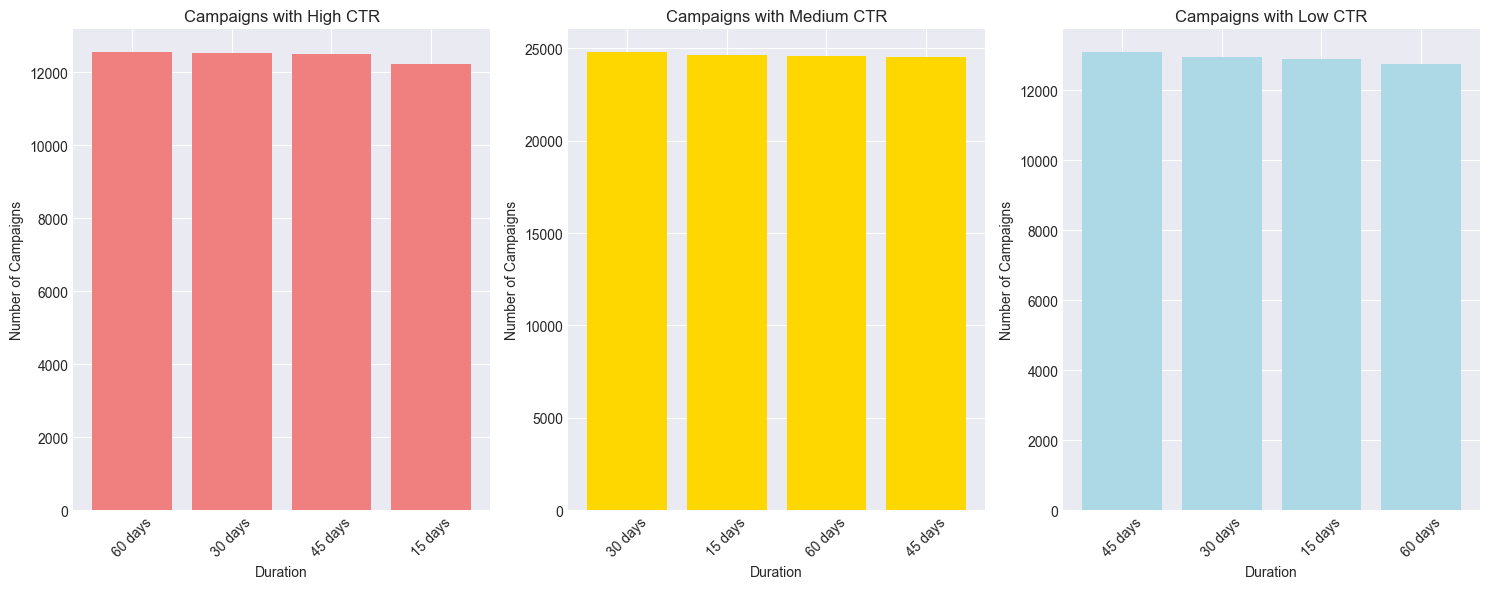

In [10]:
# Most Duration Spent on Campaigns with High CTR
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# High CTR (≥ 0.17)
high_ctr = df[df['CTR'] >= 0.17]
axs[0].bar(
    high_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    high_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='lightcoral'
)
axs[0].set_xlabel('Duration')
axs[0].set_ylabel('Number of Campaigns')
axs[0].set_title('Campaigns with High CTR')
axs[0].tick_params(axis='x', rotation=45)

# Medium CTR (بين 0.06 و 0.17)
medium_ctr = df[(df['CTR'] < 0.17) & (df['CTR'] > 0.06)]
axs[1].bar(
    medium_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    medium_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='gold'
)
axs[1].set_xlabel('Duration')
axs[1].set_ylabel('Number of Campaigns')
axs[1].set_title('Campaigns with Medium CTR')
axs[1].tick_params(axis='x', rotation=45)

# Low CTR (≤ 0.06)
low_ctr = df[df['CTR'] <= 0.06]
axs[2].bar(
    low_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).index,
    low_ctr.groupby('Duration')['Campaign_ID'].nunique().sort_values(ascending=False).values,
    color='lightblue'
)
axs[2].set_xlabel('Duration')
axs[2].set_ylabel('Number of Campaigns')
axs[2].set_title('Campaigns with Low CTR')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# as we can  see some companies have more campaigns with high CTR than others, 
# and the duration of 30 days seems to be the most common among high CTR campaigns. 
# this could indicate that a 30-day campaign duration is optimal for achieving higher engagement rates. 
# Further analysis could be done to understand why certain companies are performing better 
# and if there are specific strategies they are using that contribute to their success.

df[(df['CTR'] >= 0.17) & (df['Duration'] == '30 days')].groupby('Company')['Campaign_ID'].nunique()

Company
Alpha Innovations      2477
DataTech Solutions     2505
Innovate Industries    2514
NexGen Systems         2498
TechCorp               2545
Name: Campaign_ID, dtype: int64

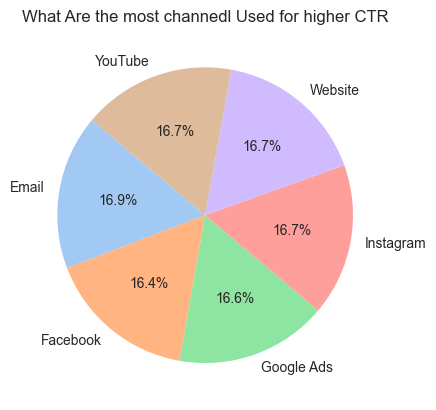

In [12]:
# Let's See What Are the most channedl Used for higher CTR

# Channel_Used

plt.Figure(figsize=(12,8))
plt.pie(df[(df['CTR'] >= 0.17)].groupby('Channel_Used')['Campaign_ID'].nunique().values,
        labels=df[(df['CTR'] >= 0.17)].groupby('Channel_Used')['Campaign_ID'].nunique().index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel')
)
plt.title("What Are the most channedl Used for higher CTR")
plt.show()

In [13]:
# Do people click but not buy?
df["Conversion_Rate"].describe()

count   200005.00
mean         0.08
std          0.04
min          0.01
25%          0.05
50%          0.08
75%          0.12
max          0.15
Name: Conversion_Rate, dtype: float64

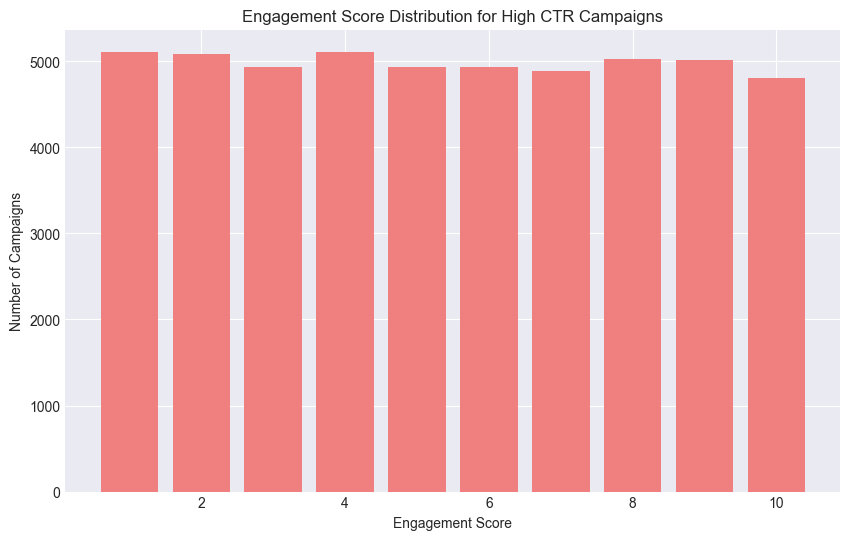

In [14]:
# Engagement_Score For Higher CTR Which Indicates is higher CTR increes Engagement_Score or it just for furuous 
plt.figure(figsize=(10, 6))
plt.bar(df[(df['CTR'] >= 0.17)].groupby('Engagement_Score')['Campaign_ID'].nunique().sort_values(ascending=False).index,
        df[(df['CTR'] >= 0.17)].groupby('Engagement_Score')['Campaign_ID'].nunique().sort_values(ascending=False).values,
        color='lightcoral')
plt.title('Engagement Score Distribution for High CTR Campaigns')
plt.xlabel('Engagement Score')
plt.ylabel('Number of Campaigns')
plt.show()
# we find that despite the higher CTR almost 25,000 from 50,000has less than or equal 5 Engagement_Score out of 10 

In [15]:
# - فضول.
# - الحملات اللي CTR عالي + Engagement عالي → دي اللي فعلاً قوية.
# - الحملات اللي CTR عالي + Engagement ضعيف → محتاجة تحسين في المحتوى أو تجربة المستخدم.


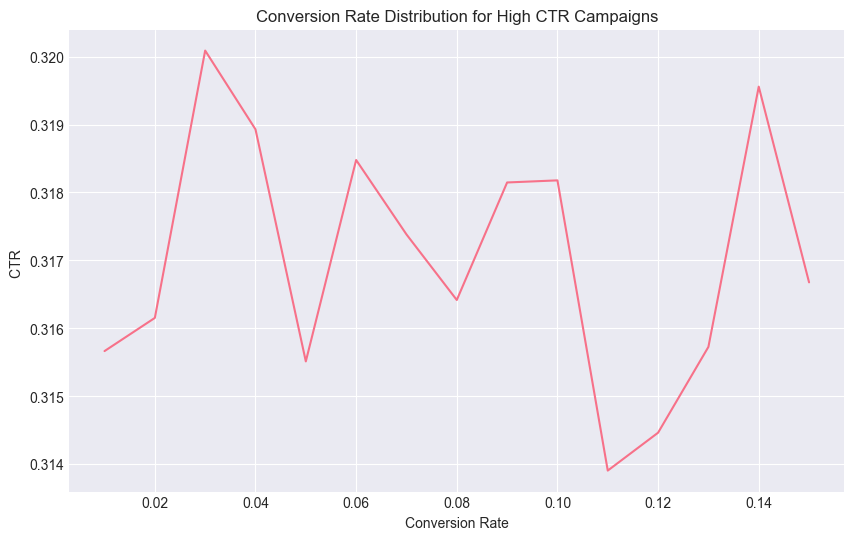

In [16]:
# Conversion_Rate For Higher CTR Which Indicates is higher CTR increes Conversion_Rate or it just for furuous 

plt.figure(figsize=(10, 6))
# plt.hist(df[df['CTR'] >= 0.17]['Conversion_Rate'], bins=5, color='lightcoral', edgecolor='black')
plt.plot(
        df[(df['CTR'] >= 0.17)].groupby('Conversion_Rate')['CTR'].mean().index,
        df[(df['CTR'] >= 0.17)].groupby('Conversion_Rate')['CTR'].mean().values
)
plt.title('Conversion Rate Distribution for High CTR Campaigns')
plt.xlabel('Conversion Rate')
plt.ylabel('CTR ')
plt.show()
# we find that despite the higher CTR no relationship that higher ctr will increess Conversion_Rate

In [17]:
# Insight Peopble are clicking but not buying
# - الحملات اللي CTR عالي + Conversion Rate عالي → دي اللي فعلاً قوية.
# - الحملات اللي CTR عالي + Conversion Rate ضعيف → محتاجة تحسين في تجربة الشراء أو العروض.

In [18]:
#  Which campaigns have a perfect funnel ?
df.groupby("Campaign_Type")[["CTR","Engagement_Score","Conversion_Rate"]].mean().sort_values("CTR", ascending=False)

,CTR,Engagement_Score,Conversion_Rate
Campaign_Type,,,
Display,0.14,5.51,0.08
Social Media,0.14,5.50,0.08
Influencer,0.14,5.48,0.08
Search,0.14,5.49,0.08
Email,0.14,5.50,0.08


In [19]:
# Insight : All Campaigns have balanced funnel

## 2. Channel Performance

In [20]:
df.head(1)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,CTR,conversions
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness,0.26,20.24


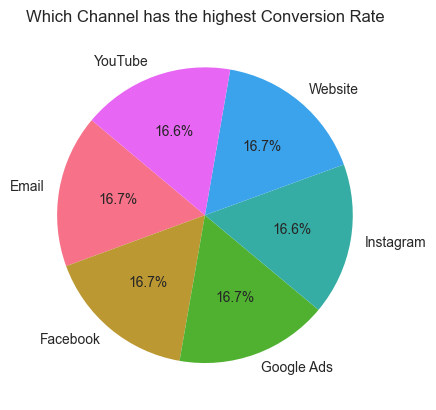

In [21]:
# Which Channel has the highest Conversion Rate
df.groupby("Channel_Used")[["Conversion_Rate"]].mean().sort_values("Conversion_Rate", ascending=False)

plt.Figure(figsize=(12,8))
plt.pie(df.groupby('Channel_Used')['Conversion_Rate'].mean().values,
        labels=df.groupby('Channel_Used')['Conversion_Rate'].mean().index, 
        autopct='%1.1f%%',
        startangle=140,
)
plt.title("Which Channel has the highest Conversion Rate")
plt.show()

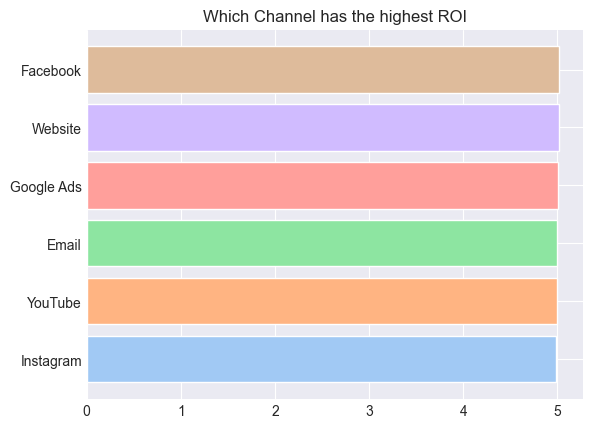

In [22]:
# Which Channel has the highest ROI

df.groupby("Channel_Used")[["ROI"]].mean().sort_values("ROI", ascending=False)

plt.Figure(figsize=(12,8))
plt.barh(df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=True).index,
         df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=True).values,
         color=sns.color_palette('pastel'),
        edgecolor='white',

)
plt.title("Which Channel has the highest ROI")
plt.show()

# ROI is a critical metric for evaluating the effectiveness of marketing campaigns, 
# as it measures the return on investment relative to the cost of the campaign. 
# ROI is calculated as (Revenue - Cost) / Cost, and it provides insights into the profitability of a campaign.
# - A high ROI indicates that the campaign is generating more revenue than it costs, which is a positive outcome for the business.
# - A low or negative ROI suggests that the campaign is not performing well and may be costing the business 
#   more than it is generating in revenue, which could indicate a need for reevaluation of the campaign strategy or execution.

In [23]:
# هل في Channel غالي ومش مربح؟
df.groupby("Channel_Used")[["ROI",'Acquisition_Cost']].mean().sort_values("Acquisition_Cost", ascending=True)

# As we can see, all channels have a similar ROI of around 5.00, 
# which indicates that they are all generating a positive return on investment.

# However, there are slight differences in acquisition costs among the channels.

# YouTube has the lowest acquisition cost at $12,481.57, 
# which could make it a more cost-effective option for acquiring customers compared to the other channels.

# On the other hand, Google Ads has the highest acquisition cost at $12,528.25, 
# which may suggest that it is more expensive to acquire customers through this channel compared to others.

# Despite the differences in acquisition costs, the similar ROI across all channels suggests that 
# they are all performing well in terms of profitability, and the choice of channel may 
# depend on other factors such as target audience, campaign goals, and overall marketing strategy.

,ROI,Acquisition_Cost
Channel_Used,,
YouTube,4.99,12481.57
Website,5.01,12487.84
Instagram,4.99,12491.76
Facebook,5.02,12510.77
Email,5.00,12526.39
Google Ads,5.00,12528.25


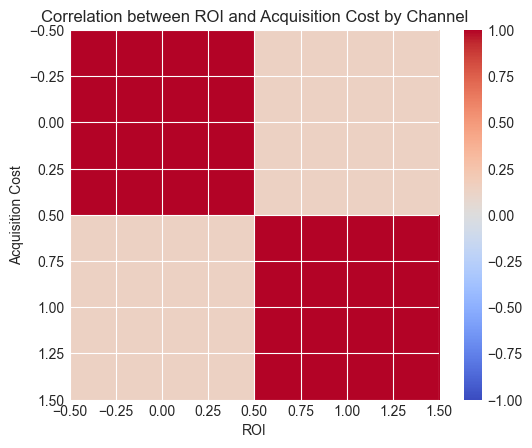

In [24]:
plt.imshow(df.groupby("Channel_Used")[["ROI",'Acquisition_Cost']].mean().sort_values("Acquisition_Cost", ascending=True)
         .corr(),
            cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
# add x and y labels
plt.xlabel("ROI")
plt.ylabel("Acquisition Cost")
plt.title("Correlation between ROI and Acquisition Cost by Channel")
plt.show()

## 3. Audience Analysis

In [32]:
df.head(15)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,CTR,conversions
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness,0.26,20.24
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas,0.02,13.92
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers,0.08,40.88
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness,0.12,23.87
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness,0.09,18.95
5,6,DataTech Solutions,Display,All Ages,15 days,Instagram,0.07,9716,4.36,New York,2021-06-01 00:00:00,100,1643,1,Foodies,0.06,7.00
6,7,NexGen Systems,Email,Women 35-44,60 days,Website,0.13,11067,2.86,Los Angeles,2021-07-01 00:00:00,817,8749,10,Tech Enthusiasts,0.09,106.21
7,8,DataTech Solutions,Search,Men 18-24,45 days,Google Ads,0.08,13280,5.55,Los Angeles,2021-08-01 00:00:00,624,7854,7,Outdoor Adventurers,0.08,49.92
8,9,Alpha Innovations,Social Media,Women 35-44,15 days,Facebook,0.09,18066,6.73,Chicago,2021-09-01 00:00:00,861,1754,6,Tech Enthusiasts,0.49,77.49
9,10,TechCorp,Email,Women 35-44,15 days,Instagram,0.09,13766,3.78,Los Angeles,2021-10-01 00:00:00,642,3856,3,Tech Enthusiasts,0.17,57.78


In [ ]:
# مين أكتر ناس بتشتري و بتستجيب للحمله؟
df.groupby('Target_Audience')['conversions'].mean().sort_values(ascending=True)

Target_Audience
All Ages      43.93
Men 18-24     44.00
Women 25-34   44.00
Women 35-44   44.08
Men 25-34     44.11
Name: conversions, dtype: float64

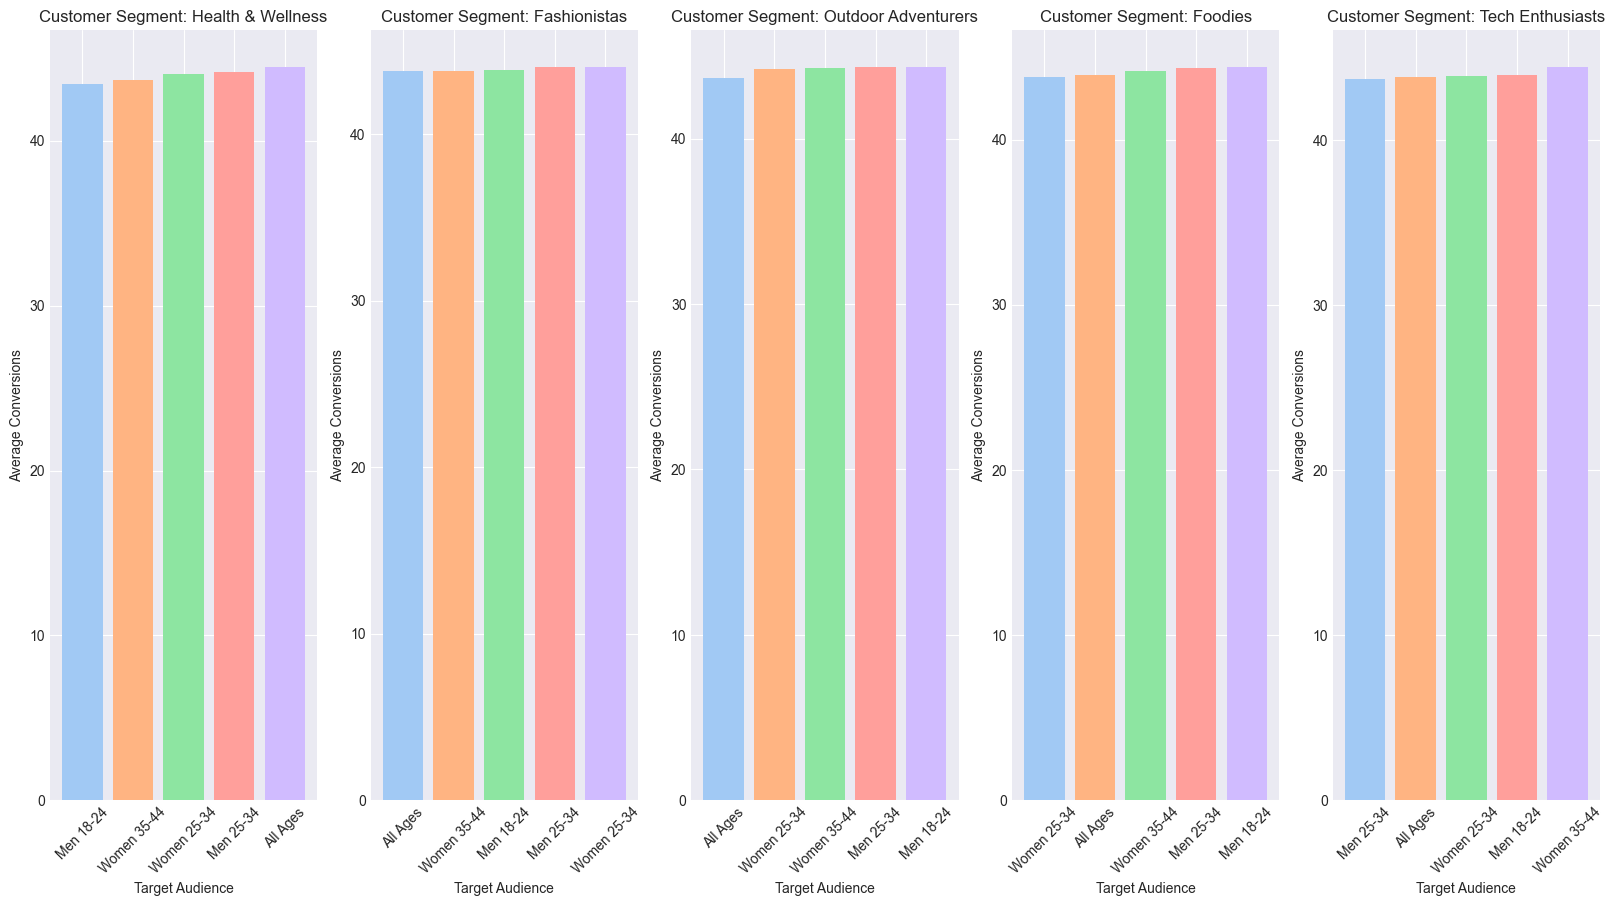

In [40]:
# مين أكتر ناس بتشتري لكل كاستمر سيجمنت؟
fig, axs = plt.subplots(1, 5, figsize=(20, 10))
for i, segment in enumerate(df['Customer_Segment'].unique()):
    segment_data = df[df['Customer_Segment'] == segment]
    axs[i].bar(segment_data.groupby('Target_Audience')['conversions'].mean().sort_values(ascending=True).index,
               segment_data.groupby('Target_Audience')['conversions'].mean().sort_values(ascending=True).values,
               color=sns.color_palette('pastel'))
    axs[i].set_title(f'Customer Segment: {segment}')
    axs[i].set_xlabel('Target Audience')
    axs[i].set_ylabel('Average Conversions')
    axs[i].tick_params(axis='x', rotation=45)

Customer_Segment
Fashionistas          0.08
Foodies               0.08
Health & Wellness     0.08
Outdoor Adventurers   0.08
Tech Enthusiasts      0.08
Name: Conversion_Rate, dtype: float64


<Axes: xlabel='Customer_Segment', ylabel='Conversion_Rate'>

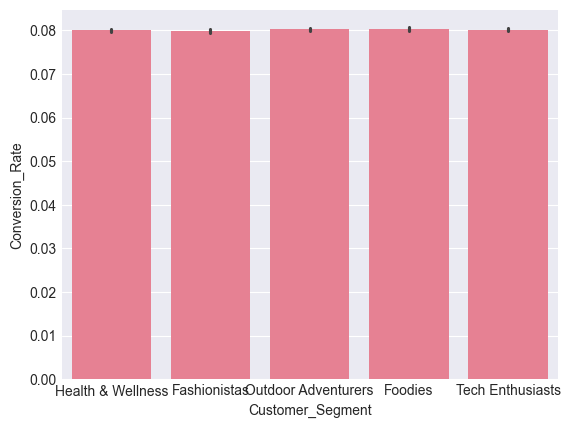

In [ ]:
# هل نوع العميل بيأثر؟
print(df.groupby("Customer_Segment")["Conversion_Rate"].mean())
sns.barplot(df, x="Customer_Segment", y="Conversion_Rate")

# As we can see, the average conversion rate is the same across all customer segments,
# which suggests that the type of customer segment does not have a significant impact on conversion rates in this dataset.

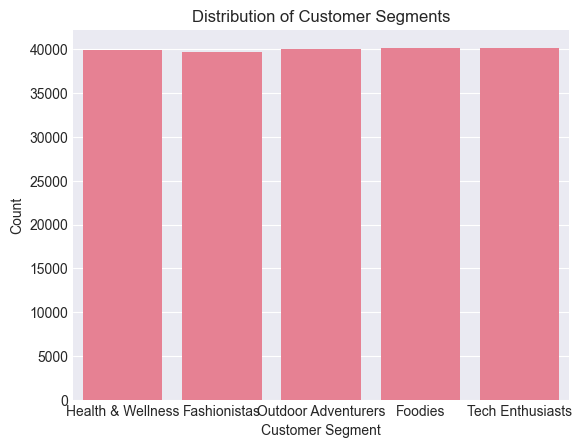

In [46]:
# What are the most common customer segments?
sns.countplot(df, x="Customer_Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.title("Distribution of Customer Segments")
plt.show()


In [ ]:
# هل في Audience high engagement؟
df.groupby("Target_Audience")["Engagement_Score"].mean()

# As we can see, the engagement scores are very similar across all target audiences, with only slight variations.
# This suggests that there is no significant difference in engagement levels among the different target audiences in this dataset.

Target_Audience
All Ages      5.49
Men 18-24     5.52
Men 25-34     5.49
Women 25-34   5.49
Women 35-44   5.49
Name: Engagement_Score, dtype: float64

<Axes: xlabel='Target_Audience', ylabel='Engagement_Score'>

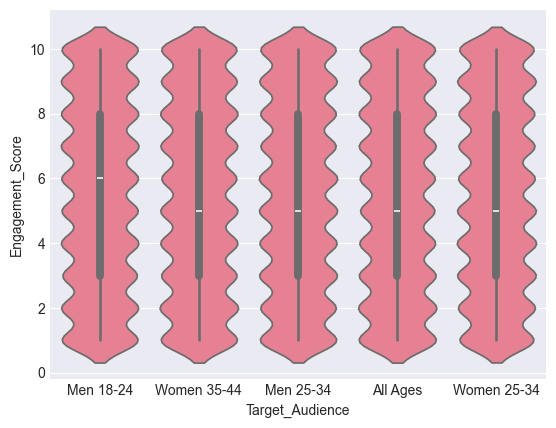

In [48]:
sns.violinplot(df, x="Target_Audience", y="Engagement_Score")